# ERCP Baseline Pipeline (Mock Model)

Dataset root: `training/dataset`  
Classes: `Biliary_Leaks`, `Lithiasis`, `Stricture`, `Normal`

This notebook provides a reusable Torch-compatible baseline with:
- configurable, modular preprocessing and augmentation pipelines
- class-imbalance strategy switching
- evaluation on all validation samples (DenseNet-style metrics)
- Grad-CAM visualization artifact generation


In [1]:
from __future__ import annotations
from dataclasses import dataclass
from enum import Enum
from pathlib import Path
from typing import Callable, Dict, List, Tuple

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

## Configuration
Define dataset paths, class labels, and run modes.


In [3]:
DATASET_ROOT = Path('dataset')
ARTIFACT_DIR = Path('models')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ['Biliary_Leaks', 'Lithiasis', 'Stricture', 'Normal']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

class ImbalanceMode(str, Enum):
    NORMAL = 'normal'
    WEIGHTED_LOSS = 'weighted_loss'
    UNIFORM_SAMPLING = 'uniform_sampling'


## Pipeline Configuration
Set modular preprocessing, augmentation, and run-time configuration objects.


In [4]:
@dataclass
class PreprocessStep:
    name: str
    enabled: bool = True

@dataclass
class AugmentStep:
    name: str
    enabled: bool = True
    prob: float = 1.0

@dataclass
class PreprocessConfig:
    resize: Tuple[int, int] = (512, 512)
    clahe_clip_limit: float = 2.0
    clahe_tile_grid: Tuple[int, int] = (8, 8)
    steps: Tuple[PreprocessStep, ...] = (
        PreprocessStep('clahe', enabled=True),
        PreprocessStep('resize', enabled=True),
    )

@dataclass
class AugmentConfig:
    rotation_deg: float = 40.0
    zoom_factor: float = 1.2
    brightness_delta: float = 0.2
    blur_kernel: int = 3
    preserve_border: bool = True
    steps: Tuple[AugmentStep, ...] = (
        AugmentStep('brightness', enabled=True, prob=0.7),
        AugmentStep('blur', enabled=True, prob=0.4),
        AugmentStep('rotation', enabled=True, prob=0.7),
        AugmentStep('zoom', enabled=True, prob=0.6),
    )

@dataclass
class RunConfig:
    imbalance_mode: ImbalanceMode = ImbalanceMode.NORMAL
    batch_size: int = 8
    num_workers: int = 0
    lr: float = 1e-3
    epochs: int = 80
    use_gradcam: bool = True


In [5]:
PREPROCESS_REGISTRY: Dict[str, Callable[[np.ndarray, PreprocessConfig], np.ndarray]] = {}

def register_preprocess(name: str):
    def deco(fn):
        PREPROCESS_REGISTRY[name] = fn
        return fn
    return deco

@register_preprocess('clahe')
def preprocess_clahe(img_bgr: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=cfg.clahe_clip_limit, tileGridSize=cfg.clahe_tile_grid)
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

@register_preprocess('resize')
def preprocess_resize(img_bgr: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    return cv2.resize(img_bgr, cfg.resize, interpolation=cv2.INTER_AREA)

def apply_preprocessing_pipeline(img_bgr: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    out = img_bgr
    for step in cfg.steps:
        if not step.enabled:
            continue
        fn = PREPROCESS_REGISTRY.get(step.name)
        if fn is None:
            raise ValueError(f'Unknown preprocessing step: {step.name}')
        out = fn(out, cfg)
    return out


## Image Preprocessing and Augmentation
Register reusable preprocessing steps and augmentation operations.


In [6]:
def detect_content_bbox(img_bgr: np.ndarray, threshold: int = 8):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(gray > threshold)
    if len(xs) == 0 or len(ys) == 0:
        return 0, 0, img_bgr.shape[1], img_bgr.shape[0]
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    return x0, y0, x1, y1

def border_preserving_zoom(img_bgr: np.ndarray, zoom_factor: float) -> np.ndarray:
    if zoom_factor <= 1.0:
        return img_bgr

    # Determine content bbox and work on the ROI
    h, w = img_bgr.shape[:2]
    x0, y0, x1, y1 = detect_content_bbox(img_bgr)
    roi = img_bgr[y0:y1+1, x0:x1+1]
    rh, rw = roi.shape[:2]

    # Create a mask of 'content' pixels (non-dark). We'll preserve dark border pixels.
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_roi = gray[y0:y1+1, x0:x1+1]
    mask = gray_roi > 8  # keep same threshold as detect_content_bbox default

    # Compute a central crop of the ROI, upscale it back to ROI size
    zh, zw = max(1, int(rh / zoom_factor)), max(1, int(rw / zoom_factor))
    cy, cx = rh // 2, rw // 2
    sy, sx = max(0, cy - zh // 2), max(0, cx - zw // 2)
    crop = roi[sy:sy+zh, sx:sx+zw]
    zoomed = cv2.resize(crop, (rw, rh), interpolation=cv2.INTER_LINEAR)

    # Blend: only replace pixels where mask==True (content) AND zoomed pixel is not near-black
    out = img_bgr.copy()
    if mask.any():
        # compute where zoomed image actually has content (avoid copying black corners from rotation)
        zoomed_gray = cv2.cvtColor(zoomed, cv2.COLOR_BGR2GRAY)
        zoom_mask = zoomed_gray > 8
        final_mask = mask & zoom_mask
        if final_mask.any():
            mask3 = np.repeat(final_mask[:, :, None], 3, axis=2)
            roi_out = out[y0:y1+1, x0:x1+1]
            roi_out[mask3] = zoomed[mask3]
            out[y0:y1+1, x0:x1+1] = roi_out

    return out

def augment_brightness(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    alpha = 1.0 + np.random.uniform(-cfg.brightness_delta, cfg.brightness_delta)
    return cv2.convertScaleAbs(img_bgr, alpha=alpha, beta=0)

def augment_blur(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    k = max(1, int(cfg.blur_kernel))
    if k % 2 == 0:
        k += 1
    return cv2.GaussianBlur(img_bgr, (k, k), 0)

def augment_rotation(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    ang = np.random.uniform(-cfg.rotation_deg, cfg.rotation_deg)
    h, w = img_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1.0)
    return cv2.warpAffine(img_bgr, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

def augment_zoom(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    if cfg.preserve_border:
        return border_preserving_zoom(img_bgr, cfg.zoom_factor)
    return img_bgr

AUGMENT_REGISTRY: Dict[str, Callable[[np.ndarray, AugmentConfig], np.ndarray]] = {
    'brightness': augment_brightness,
    'blur': augment_blur,
    'rotation': augment_rotation,
    'zoom': augment_zoom,
}

def apply_augmentation_pipeline(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    out = img_bgr.copy()
    for step in cfg.steps:
        if not step.enabled:
            continue
        if np.random.rand() > float(step.prob):
            continue
        fn = AUGMENT_REGISTRY.get(step.name)
        if fn is None:
            raise ValueError(f'Unknown augmentation step: {step.name}')
        out = fn(out, cfg)
    return out


In [7]:
def ensure_three_channel(img_bgr: np.ndarray) -> np.ndarray:
    if img_bgr.ndim == 2:
        return np.repeat(img_bgr[:, :, None], 3, axis=2)
    if img_bgr.ndim == 3 and img_bgr.shape[-1] == 1:
        return np.repeat(img_bgr, 3, axis=2)
    if img_bgr.ndim == 3 and img_bgr.shape[-1] == 4:
        return img_bgr[:, :, :3]
    return img_bgr


def image_to_tensor(img_bgr: np.ndarray) -> torch.Tensor:
    img_bgr = ensure_three_channel(np.ascontiguousarray(img_bgr))
    return torch.from_numpy(img_bgr.transpose(2, 0, 1)).float().div(255.0)


def load_and_transform_image(image_path: str, pre_cfg: PreprocessConfig, aug_cfg: AugmentConfig | None, train: bool):
    img_bgr = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_bgr is None:
        raise FileNotFoundError(f'Could not read image: {image_path}')
    img_bgr = ensure_three_channel(img_bgr)
    img_bgr = apply_preprocessing_pipeline(img_bgr, pre_cfg)
    if train and aug_cfg is not None:
        img_bgr = apply_augmentation_pipeline(img_bgr, aug_cfg)
    return image_to_tensor(img_bgr)


In [8]:
def collect_split_samples(split: str) -> List[Tuple[Path, int]]:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        return []
    samples: List[Tuple[Path, int]] = []
    for cname in CLASSES:
        cdir = split_dir / cname
        if not cdir.exists():
            continue
        for p in cdir.glob('*.png'):
            samples.append((p, CLASS_TO_IDX[cname]))
    return samples

train_samples = collect_split_samples('train')
val_samples = collect_split_samples('val')  # strict protocol; may be empty
test_samples = collect_split_samples('test')
print('train/val/test:', len(train_samples), len(val_samples), len(test_samples))


train/val/test: 1067 234 267


In [9]:
class ERCPDataset(Dataset):
    def __init__(self, samples, pre_cfg: PreprocessConfig, aug_cfg: AugmentConfig | None = None, train: bool = False):
        self.samples = samples
        self.pre_cfg = pre_cfg
        self.aug_cfg = aug_cfg
        self.train = train

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image_path = str(path)
        x = load_and_transform_image(image_path, self.pre_cfg, self.aug_cfg, self.train)
        return x, torch.tensor(label, dtype=torch.long), image_path


## Model Definition
Define the baseline mock model architecture.


In [10]:
class MockModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        f = self.features(x).flatten(1)
        return self.classifier(f)


## Data Loaders and Imbalance Strategy
Build train loader and imbalance-aware sampling or loss behavior.


In [11]:
def build_train_loader(samples, pre_cfg, aug_cfg, run_cfg):
    ds = ERCPDataset(samples, pre_cfg, aug_cfg=aug_cfg, train=True)
    if run_cfg.imbalance_mode == ImbalanceMode.UNIFORM_SAMPLING:
        labels = np.array([y for _, y in samples])
        counts = np.bincount(labels, minlength=len(CLASSES)) + 1e-6
        w = 1.0 / counts
        sw = np.array([w[y] for y in labels], dtype=np.float32)
        sampler = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
        return DataLoader(ds, batch_size=run_cfg.batch_size, sampler=sampler, num_workers=run_cfg.num_workers)
    return DataLoader(ds, batch_size=run_cfg.batch_size, shuffle=True, num_workers=run_cfg.num_workers)

def class_weights_from_samples(samples):
    labels = np.array([y for _, y in samples])
    counts = np.bincount(labels, minlength=len(CLASSES)) + 1e-6
    w = counts.sum() / counts
    return torch.tensor(w, dtype=torch.float32)


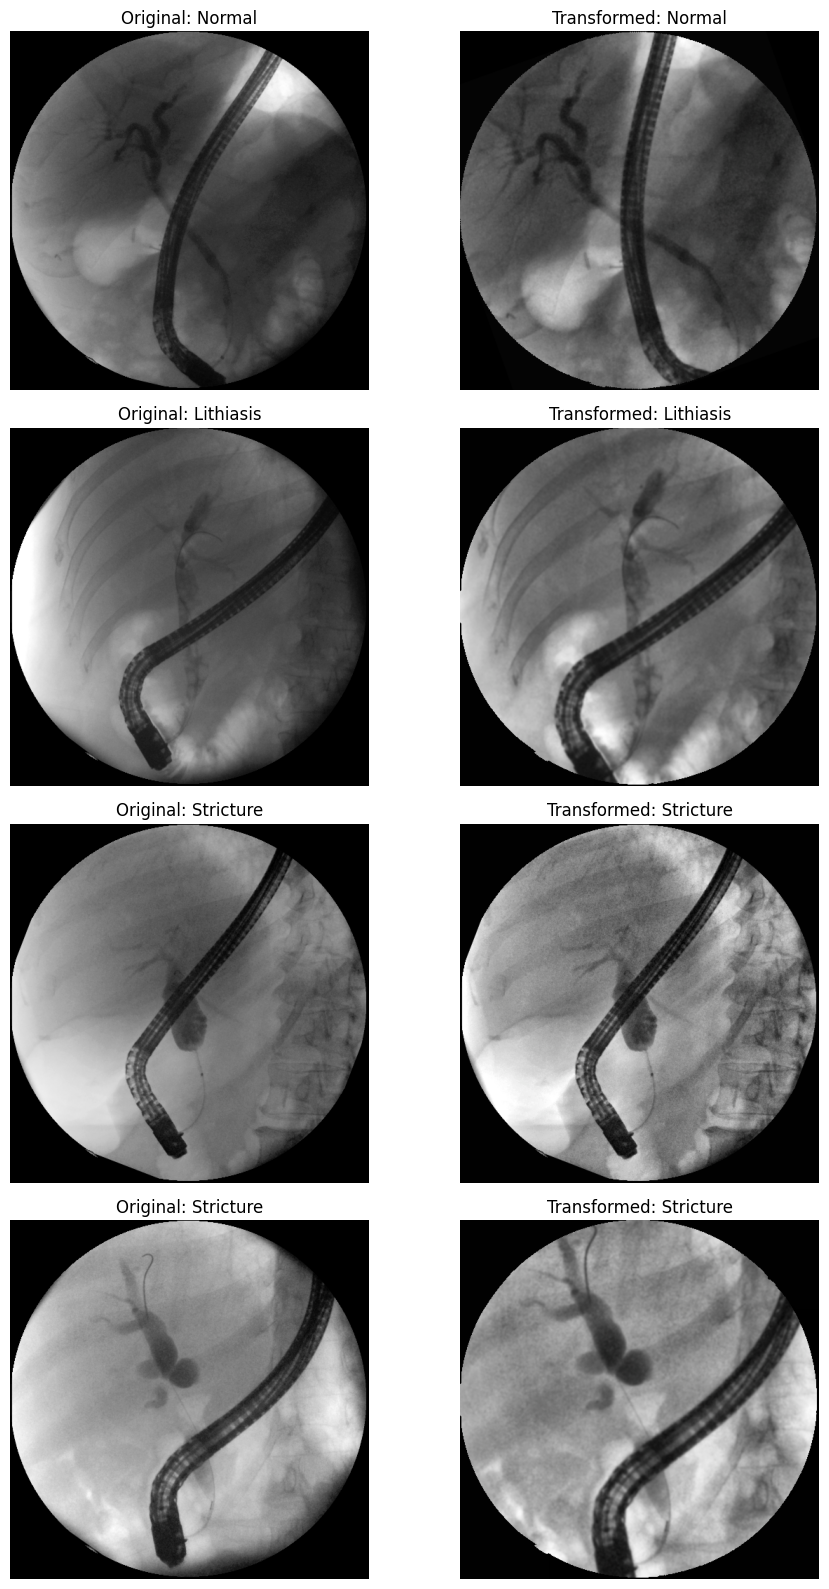

In [12]:
def show_pre_post_transform_examples(samples, pre_cfg: PreprocessConfig, aug_cfg: AugmentConfig | None, n_examples: int = 4):
    if not samples:
        print('No samples available for preview.')
        return

    preview_count = min(int(n_examples), len(samples))
    preview_ds = ERCPDataset(samples, pre_cfg, aug_cfg=aug_cfg, train=True)
    indices = np.random.choice(len(samples), size=preview_count, replace=False)
    fig, axes = plt.subplots(preview_count, 2, figsize=(10, 4 * preview_count))
    if preview_count == 1:
        axes = np.array([axes])

    for row, idx in enumerate(indices):
        path, label = samples[idx]
        raw = cv2.imread(str(path))
        if raw is None:
            raw = np.zeros((pre_cfg.resize[1], pre_cfg.resize[0], 3), dtype=np.uint8)
        else:
            raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

        transformed, _, _ = preview_ds[idx]
        transformed = transformed.detach().cpu()
        if transformed.ndim == 3:
            transformed = transformed.permute(1, 2, 0).numpy()[..., ::-1]
        transformed = transformed.astype(np.float32)
        transformed -= transformed.min()
        if transformed.max() > 0:
            transformed /= transformed.max()

        axes[row, 0].imshow(raw)
        axes[row, 0].set_title(f'Original: {CLASSES[label]}')
        axes[row, 0].axis('off')
        axes[row, 1].imshow(transformed)
        axes[row, 1].set_title(f'Transformed: {CLASSES[label]}')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


preview_pre_cfg = PreprocessConfig()
preview_aug_cfg = AugmentConfig()
if train_samples:
    show_pre_post_transform_examples(train_samples, preview_pre_cfg, preview_aug_cfg, n_examples=4)


## Model Training and Evaluation
Train the model and evaluate on all validation samples with metrics and confusion matrix.


In [13]:
def evaluate_model(data_loader: DataLoader, model: nn.Module, device: str):
    predictions = []
    actual_values = []
    probs_list = []
    model.eval()

    with torch.no_grad():
        for inputs, labels, _ in tqdm(data_loader, total=len(data_loader), desc='Evaluating', leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = np.argmax(probs, axis=1)
            actual = labels.cpu().numpy()

            probs_list.append(probs)
            predictions.append(preds.reshape((-1, 1)))
            actual_values.append(actual.reshape((-1, 1)))

    if not predictions:
        return np.array([]), np.array([]), np.array([])

    predictions = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    probs_all = np.vstack(probs_list)

    f1 = f1_score(actual_values, predictions, average='macro', zero_division=0)
    acc = accuracy_score(actual_values, predictions)
    print(f'Validation Accuracy: {acc:0.4f}')
    print(f'Validation F1 (macro): {f1:0.4f}')
    return actual_values, predictions, probs_all



def compute_roc_metrics(y_true: np.ndarray, y_probs: np.ndarray):
    y_true = np.asarray(y_true).reshape(-1)
    y_probs = np.asarray(y_probs)

    if y_true.size == 0 or y_probs.size == 0:
        return 0.0, 0.0, np.array([]), np.array([])

    multiclass_auc = 0.0
    binary_auc = 0.0
    disease_true = np.array([])
    disease_scores = np.array([])

    try:
        y_true_bin = label_binarize(y_true, classes=list(range(y_probs.shape[1])))
        multiclass_auc = float(roc_auc_score(y_true_bin, y_probs, average='macro'))
    except ValueError:
        multiclass_auc = 0.0

    if 'Normal' in CLASS_TO_IDX and y_probs.shape[1] > CLASS_TO_IDX['Normal']:
        normal_idx = CLASS_TO_IDX['Normal']
        disease_true = (y_true != normal_idx).astype(int)
        disease_scores = 1.0 - y_probs[:, normal_idx]
        try:
            binary_auc = float(roc_auc_score(disease_true, disease_scores))
        except ValueError:
            binary_auc = 0.0

    return multiclass_auc, binary_auc, disease_true, disease_scores



def display_roc_curve(y_true: np.ndarray, y_probs: np.ndarray, filename: str):
    multiclass_auc, binary_auc, disease_true, disease_scores = compute_roc_metrics(y_true, y_probs)
    if disease_true.size == 0 or disease_scores.size == 0:
        return

    if np.unique(disease_true).size < 2:
        return

    fpr, tpr, _ = roc_curve(disease_true, disease_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Disease vs Normal ROC AUC = {binary_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Final Epoch ROC Curve (multiclass AUC = {multiclass_auc:.4f})')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


class Trainer:
    def __init__(self, train_samples, val_samples):
        self.train_samples = train_samples
        self.val_samples = val_samples

    def train(self, model: nn.Module, optimizer, num_iterations: int | None, epochs: int | None,
              save_dir: Path, model_name: str, preprocess_config: PreprocessConfig,
              augmentation_config: AugmentConfig, run_config: RunConfig):
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model = model.to(device)
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        train_loader = build_train_loader(self.train_samples, preprocess_config, augmentation_config, run_config)
        val_loader = None
        if self.val_samples:
            val_loader = DataLoader(
                ERCPDataset(self.val_samples, preprocess_config, train=False),
                batch_size=run_config.batch_size,
                shuffle=False,
                num_workers=run_config.num_workers,
            )

        cw = class_weights_from_samples(self.train_samples).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw if run_config.imbalance_mode == ImbalanceMode.WEIGHTED_LOSS else None)
        print(epochs, num_iterations)
        total_epochs = int(epochs if epochs is not None else max(1, int(num_iterations or 1)))
        plot_path = ARTIFACT_DIR / f'{Path(model_name).stem}_training_curve.png'
        liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=str(plot_path))])
        best_metric = -1.0
        best_metric_epoch = -1
        best_train_f1 = 0.0
        epochs_without_improvement = 0
        last_val_true = np.array([])
        last_val_probs = np.array([])

        def evaluate_epoch(loader):
            model.eval()
            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_targets = []
            all_probs = []

            with torch.no_grad():
                for inputs, labels, _ in loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    logits = model(inputs)
                    probs = torch.softmax(logits, dim=1)
                    loss = criterion(logits, labels)
                    running_loss += loss.item() * inputs.size(0)
                    preds = probs.argmax(dim=1)
                    running_corrects += (preds == labels).sum().item()
                    all_preds.append(preds.detach().cpu())
                    all_targets.append(labels.detach().cpu())
                    all_probs.append(probs.detach().cpu())

            if not all_preds:
                return 0.0, 0.0, 0.0, 0.0, np.array([]), np.array([]), 0.0

            y_pred = torch.cat(all_preds).numpy()
            y_true = torch.cat(all_targets).numpy()
            y_probs = torch.cat(all_probs).numpy()
            avg_loss = running_loss / len(loader.dataset)
            avg_acc = running_corrects / len(loader.dataset)
            avg_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
            avg_roc, binary_roc, _, _ = compute_roc_metrics(y_true, y_probs)
            return avg_loss, avg_acc, avg_f1, avg_roc, y_true, y_probs, binary_roc

        for epoch in range(total_epochs):
            model.train()
            train_running_loss = 0.0
            train_running_corrects = 0
            train_preds = []
            train_targets = []
            train_bar = tqdm(train_loader, total=len(train_loader), desc=f'Training epoch {epoch + 1}/{total_epochs}', leave=False)

            for x, y, _ in train_bar:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                logits = model(x)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

                train_running_loss += loss.item() * x.size(0)
                preds = logits.argmax(dim=1)
                train_running_corrects += (preds == y).sum().item()
                train_preds.append(preds.detach().cpu())
                train_targets.append(y.detach().cpu())
                train_bar.set_postfix(loss=f'{loss.item():.4f}')

            train_loss = train_running_loss / len(train_loader.dataset)
            train_acc = train_running_corrects / len(train_loader.dataset)
            train_f1 = f1_score(torch.cat(train_targets).numpy(), torch.cat(train_preds).numpy(), average='macro', zero_division=0)

            val_loss = 0.0
            val_acc = 0.0
            val_f1 = 0.0
            val_roc = 0.0
            val_binary_roc = 0.0
            if val_loader is not None:
                val_loss, val_acc, val_f1, val_roc, last_val_true, last_val_probs, val_binary_roc = evaluate_epoch(val_loader)

            logs = {
                'loss': train_loss,
                'accuracy': train_acc,
                'val_loss': val_loss,
                'val_accuracy': val_acc,
                'val_F1': val_f1,
                'val_roc_auc': val_roc,
                'val_roc_auc_binary': val_binary_roc,
            }
            liveloss.update(logs)
            liveloss.send()

            current_metric = val_f1 if val_loader is not None else train_f1
            if current_metric > best_metric:
                best_metric = current_metric
                best_metric_epoch = epoch + 1
                best_train_f1 = train_f1
                torch.save(model.state_dict(), save_dir / model_name)
                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if val_loader is not None and epochs_without_improvement >= 10:
                print(
                    f'Early stopping at epoch {epoch + 1} \n'
                    f' Best Val F1: {best_metric:.4f} \n'
                    f' Best Train F1: {best_train_f1:.4f} \n'
                    f' current Val F1: {val_f1:.4f} \n'
                    f' current Train F1: {train_f1:.4f} \n'
                    f' Best epoch: {best_metric_epoch} \n'
                )
                break

            print(
                f'current epoch: {epoch + 1} current Train F1: {train_f1:.4f}'
                f' current Val F1: {val_f1:.4f}'
                f' best metric: {best_metric:.4f}'
                f' at epoch: {best_metric_epoch}'
            )

        if last_val_true.size > 0 and last_val_probs.size > 0:
            roc_path = save_dir / f'{Path(model_name).stem}_roc_final_epoch.png'
            display_roc_curve(last_val_true, last_val_probs, str(roc_path))
            print('Saved final ROC curve:', roc_path)

        print(f'train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}')
        return model

    def evaluate(self, trained_model: nn.Module, eval_loader: DataLoader, run_config: RunConfig):
        device = next(trained_model.parameters()).device
        actual_values, predictions, probs_all = evaluate_model(eval_loader, trained_model, device.type)

        metrics = {
            'per_class': {c: 0.0 for c in CLASSES},
            'aggregate': {'accuracy': 0.0, 'f1_macro': 0.0, 'roc_auc': 0.0, 'roc_auc_binary': 0.0},
            'artifacts': {'confusion_matrix': None, 'classification_report': None},
        }

        if actual_values.size > 0:
            report_text = classification_report(
                actual_values,
                predictions,
                labels=list(range(len(CLASSES))),
                target_names=CLASSES,
                digits=4,
                zero_division=0,
            )
            cm = confusion_matrix(actual_values, predictions)

            acc = accuracy_score(actual_values, predictions)
            f1 = f1_score(actual_values, predictions, average='macro', zero_division=0)
            roc_auc, roc_auc_binary, _, _ = compute_roc_metrics(actual_values, probs_all)
            metrics['aggregate']['accuracy'] = float(acc)
            metrics['aggregate']['f1_macro'] = float(f1)
            metrics['aggregate']['roc_auc'] = float(roc_auc)
            metrics['aggregate']['roc_auc_binary'] = float(roc_auc_binary)

            for i, c in enumerate(CLASSES):
                cls_mask = (actual_values.flatten() == i)
                denom = max(1, int(cls_mask.sum()))
                metrics['per_class'][c] = float((predictions.flatten()[cls_mask] == i).sum() / denom)

            cm_path = ARTIFACT_DIR / 'baseline_mock_model_cm.png'
            report_path = ARTIFACT_DIR / 'baseline_mock_model_report.txt'

            display_confusion_matrix(cm, CLASSES, str(cm_path))
            print('Classification Report:')
            print(report_text)

            report_lines = [
                'ERCP Validation Evaluation Report',
                '=' * 36,
                f"Accuracy: {metrics['aggregate']['accuracy']:.4f}",
                f"F1 Macro: {metrics['aggregate']['f1_macro']:.4f}",
                f"ROC AUC: {metrics['aggregate']['roc_auc']:.4f}",
                f"ROC AUC Binary: {metrics['aggregate']['roc_auc_binary']:.4f}",
                '',
                'Per-class Accuracy:',
            ]
            report_lines.extend([f"- {k}: {v:.4f}" for k, v in metrics['per_class'].items()])
            report_lines.extend([
                '',
                'Classification Report:',
                str(report_text),
                '',
                'Confusion Matrix:',
                str(np.array2string(cm)),
                '',
            ])
            report_path.write_text(''.join(report_lines))

            metrics['artifacts']['confusion_matrix'] = str(cm_path)
            metrics['artifacts']['classification_report'] = str(report_path)

        return metrics

## Grad-CAM Visualization
Generate class-activation maps to inspect model attention regions.


In [14]:
def  gradcam_overlay(model: nn.Module, x: torch.Tensor, target_class: int):
    model.eval()
    device = next(model.parameters()).device
    target_layer = model.blocks[-1][-1]
    print(model.blocks)
    return cam


## Smoke Run
Execute an end-to-end sanity check of training, evaluation, and Grad-CAM outputs.


In [ ]:
# Smoke run
pre_cfg = PreprocessConfig()
aug_cfg = AugmentConfig()
run_cfg = RunConfig(imbalance_mode=ImbalanceMode.UNIFORM_SAMPLING, epochs=3)
model = MockModel(num_classes=len(CLASSES))
optimizer = torch.optim.Adam(model.parameters(), lr=run_cfg.lr)
trainer = Trainer(train_samples=train_samples, val_samples=val_samples)

In [ ]:
# Proceed only when both train and val splits are available.
if len(train_samples) > 0 and len(val_samples) > 0:
        trained_model = trainer.train(
        model=model,
        optimizer=optimizer,
        num_iterations=None,
        epochs=run_cfg.epochs,
        save_dir=ARTIFACT_DIR,
        model_name='baseline_mock_model.pth',
        preprocess_config=pre_cfg,
        augmentation_config=aug_cfg,
        run_config=run_cfg,
    )

    val_loader = DataLoader(ERCPDataset(val_samples, pre_cfg, train=False), batch_size=run_cfg.batch_size, shuffle=False)
    metrics = trainer.evaluate(trained_model=trained_model, eval_loader=val_loader, run_config=run_cfg)
    print('Per-class validation metrics:', metrics['per_class'])
    print('Aggregate metrics:', metrics['aggregate'])

    # Generate one Grad-CAM artifact from validation samples.
    if run_cfg.use_gradcam:
        ds = ERCPDataset(val_samples, pre_cfg, train=False)
        x, y, p = ds[0]
        cam = gradcam_overlay(trained_model, x, int(y))
        np.save(ARTIFACT_DIR / 'gradcam_sample.npy', cam)
        print('Saved Grad-CAM:', ARTIFACT_DIR / 'gradcam_sample.npy', 'for', p)
else:
    print('Skipped smoke run: train and/or val split is empty.')


## GRAD CAM

In [17]:
if run_cfg.use_gradcam:
        ds = ERCPDataset(val_samples, pre_cfg, train=False)
        x, y, p = ds[0]
        cam = gradcam_overlay(trained_model, x, int(y))
        np.save(ARTIFACT_DIR / 'gradcam_sample.npy', cam)
        print('Saved Grad-CAM:', ARTIFACT_DIR / 'gradcam_sample.npy', 'for', p)

NameError: name 'trained_model' is not defined